In [ ]:
from google.colab import drive
drive.mount('/content/drive')
curr_dir = "/content/drive/MyDrive/TURKM_MORPH"
%cd "$curr_dir"
print(f"✅ Рабочая директория: {curr_dir}")

Mounted at /content/drive
/content/drive/MyDrive/TURKM_MORPH
✅ Рабочая директория: /content/drive/MyDrive/TURKM_MORPH


In [ ]:
# ==== SETTINGS ====
INPUT_FILE = "Text_human_evaluation_319.txt"   # загрузите файл в Colab
OUTPUT_FILE = "turkmen_expert_table.xlsx"



# ===== 2. Установка библиотеки =====
!pip install -q openpyxl

# ===== 3. Импорт =====
import re
from openpyxl import Workbook
from openpyxl.styles import Font, Alignment
from openpyxl.worksheet.datavalidation import DataValidation

# ===== 4. Функции =====
def is_real_word(word):
    # Оставляем только элементы, где есть хотя бы одна буква
    return re.search(r"[A-Za-zÄÖÜÝÇŞŇŽäöüýçşňž]", word) is not None

def reconstruct_segments(line):
    """
    Собирает полные сегментации слов по правилу:
    если токен содержит @@, слово продолжается;
    если токен без @@, это конец слова.
    """
    segments = []
    current_parts = []

    tokens = line.strip().split()

    for tok in tokens:
        current_parts.append(tok)

        # если в токене нет @@, значит это конец слова
        if "@@" not in tok:
            seg = " ".join(current_parts)
            segments.append(seg)
            current_parts = []

    # если строка оборвалась на незавершенном слове
    if current_parts:
        seg = " ".join(current_parts)
        segments.append(seg)

    return segments

def segmentation_to_word(seg):
    """
    aralygy@@ nda -> aralygynda
    institut@@ yn@@ da -> institutynda
    """
    return seg.replace("@@ ", "").replace("@@", "")

def count_morphemes(seg):
    return seg.count("@@") + 1

# ===== 5. Создание Excel =====
wb = Workbook()
ws = wb.active
ws.title = "Turkmen Expert Table"

instruction = (
    "Инструкция: заполните колонку D (TRUE / FALSE / PARTIAL). "
    "Если FALSE или PARTIAL — напишите правильную сегментацию в колонке E через @@ "
    "(например: adam@@ lar@@ yň)"
)

ws.merge_cells(start_row=1, start_column=1, end_row=1, end_column=6)
ws.cell(row=1, column=1).value = instruction
ws.cell(row=1, column=1).font = Font(bold=True)
ws.cell(row=1, column=1).alignment = Alignment(wrap_text=True)

headers = [
    "Слово",
    "Сегментация FEMSeg",
    "Морфем",
    "Верно? (TRUE/FALSE/PARTIAL)",
    "Правильная сегментация",
    "Комментарий"
]

for col, h in enumerate(headers, 1):
    ws.cell(row=2, column=col).value = h
    ws.cell(row=2, column=col).font = Font(bold=True)

row = 3

# ===== 6. Чтение файла и заполнение таблицы =====
with open(INPUT_FILE, "r", encoding="utf-8") as f:
    for line in f:
        segs = reconstruct_segments(line)

        for seg in segs:
            word = segmentation_to_word(seg)

            # пропускаем пунктуацию и разделители
            if not is_real_word(word):
                continue

            ws.cell(row=row, column=1).value = word
            ws.cell(row=row, column=2).value = seg
            ws.cell(row=row, column=3).value = count_morphemes(seg)
            row += 1

# ===== 7. Выпадающий список =====
dv = DataValidation(type="list", formula1='"TRUE,FALSE,PARTIAL"', allow_blank=True)
ws.add_data_validation(dv)
dv.add(f"D3:D{row}")

# ===== 8. Ширина колонок =====
widths = [25, 40, 10, 28, 40, 35]
for i, w in enumerate(widths, 1):
    ws.column_dimensions[chr(64 + i)].width = w

# ===== 9. Сохранение =====
wb.save(OUTPUT_FILE)
print("Готово:", OUTPUT_FILE)



Готово: turkmen_expert_table.xlsx


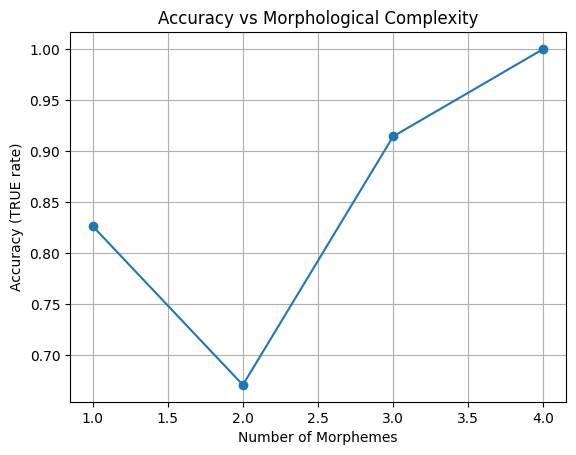

In [ ]:
import pandas as pd
from openpyxl import load_workbook
import matplotlib.pyplot as plt

# загрузка файла
file_path = "turkmen_expert_table_12_04.xlsx"

wb = load_workbook(file_path)
ws = wb.active

data = []
for row in ws.iter_rows(min_row=3, values_only=True):
    data.append(row)

df = pd.DataFrame(data, columns=["word","pred","morph","label","gold","comment"])

df["label"] = df["label"].astype(str).str.strip().str.upper()
df["morph"] = pd.to_numeric(df["morph"], errors="coerce")

# считаем accuracy по числу морфем
acc_by_morph = df.groupby("morph")["label"].apply(lambda x: (x=="TRUE").mean())

# ==== ВАЖНО: показываем график ====
plt.figure()
acc_by_morph.plot(marker='o')
plt.xlabel("Number of Morphemes")
plt.ylabel("Accuracy (TRUE rate)")
plt.title("Accuracy vs Morphological Complexity")
plt.grid()

plt.show()